In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print("ابعاد داده:", df.shape)
print("\nLabel distribution:")
print(df['target'].value_counts())
print("\nFeature names (first 5):")
print(list(data.feature_names)[:5])

ابعاد داده: (569, 31)

Label distribution:
target
1    357
0    212
Name: count, dtype: int64

Feature names (first 5):
[np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness')]


In [3]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # حفظ نسبت کلاس‌ها در هر دو مجموعه
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("\nLabel distribution in training set:")
print(y_train.value_counts())
print("\nLabel distribution in test set:")
print(y_test.value_counts())

Training set shape: (455, 30)
Test set shape: (114, 30)

Label distribution in training set:
target
1    285
0    170
Name: count, dtype: int64

Label distribution in test set:
target
1    72
0    42
Name: count, dtype: int64


In [4]:
RANDOM_STATE = 42

dt_model = DecisionTreeClassifier(random_state=RANDOM_STATE)

rf_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)

ada_model = AdaBoostClassifier(n_estimators=100, random_state=RANDOM_STATE)

gb_model = GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE)

models = {
    'Decision Tree': dt_model,
    'Random Forest': rf_model,
    'AdaBoost': ada_model,
    'Gradient Boosting': gb_model
}

trained_models = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"{name} trained!\n")

Training Decision Tree...
Decision Tree trained!

Training Random Forest...
Random Forest trained!

Training AdaBoost...
Random Forest trained!

Training AdaBoost...
AdaBoost trained!

Training Gradient Boosting...
AdaBoost trained!

Training Gradient Boosting...
Gradient Boosting trained!

Gradient Boosting trained!



In [5]:
results = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1
    }

results_df = pd.DataFrame(results).T
results_df = results_df.round(4)

print("Model evaluation results on the test set:")
results_df

Model evaluation results on the test set:


,Accuracy,Precision,Recall,F1-score
Decision Tree,0.9123,0.9559,0.9028,0.9286
Random Forest,0.9561,0.9589,0.9722,0.9655
AdaBoost,0.9561,0.9467,0.9861,0.9660
Gradient Boosting,0.9561,0.9467,0.9861,0.9660


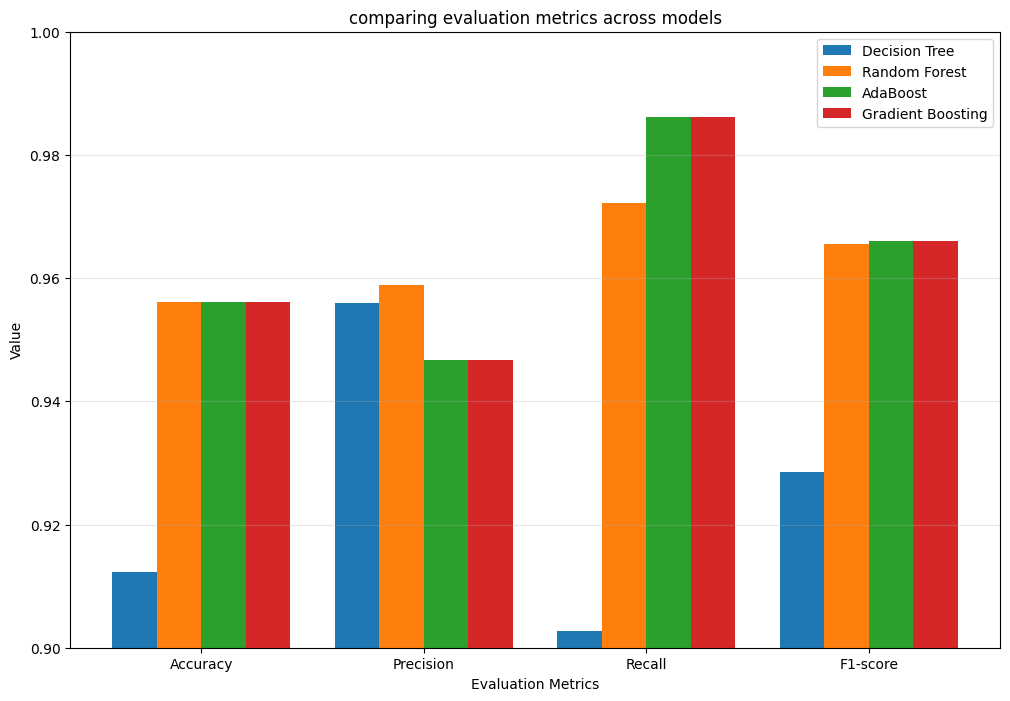


Most important features for each model:

Decision Tree:
  - worst radius: 0.6978
  - worst concave points: 0.1161
  - worst texture: 0.0589
  - texture error: 0.0527
  - worst concavity: 0.0163

Random Forest:
  - worst area: 0.1400
  - worst concave points: 0.1295
  - worst radius: 0.0977
  - mean concave points: 0.0909
  - worst perimeter: 0.0722

Conclusion:

Best model by F1-score: AdaBoost with score 0.9660

Analysis:
- All models perform very well (F1 > 0.95)
- Ensemble models (Random Forest, AdaBoost, Gradient Boosting) typically outperform a single decision tree
- Gradient Boosting and Random Forest usually provide the most stable results


In [6]:
plt.figure(figsize=(12, 8))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
x = np.arange(len(metrics))
width = 0.2

for i, (name, scores) in enumerate(results.items()):
    plt.bar(x + i*width, [scores[metric] for metric in metrics], width, label=name)

plt.xlabel('Evaluation Metrics')
plt.ylabel('Value')
plt.title('comparing evaluation metrics across models')
plt.xticks(x + width*1.5, metrics)
plt.legend()
plt.ylim(0.9, 1.0)  # تنظیم محدوده y برای دید بهتر تفاوت‌ها
plt.grid(axis='y', alpha=0.3)
plt.show()

print("\n" + "="*60)
print("Most important features for each model:")

dt_importance = trained_models['Decision Tree'].feature_importances_
top_5_dt = np.argsort(dt_importance)[-5:][::-1]
print(f"\nDecision Tree:")
for i in top_5_dt:
    print(f"  - {data.feature_names[i]}: {dt_importance[i]:.4f}")

rf_importance = trained_models['Random Forest'].feature_importances_
top_5_rf = np.argsort(rf_importance)[-5:][::-1]
print(f"\nRandom Forest:")
for i in top_5_rf:
    print(f"  - {data.feature_names[i]}: {rf_importance[i]:.4f}")

print("\n" + "="*60)
print("Conclusion:")
best_model = results_df['F1-score'].idxmax()
best_score = results_df['F1-score'].max()
print(f"\nBest model by F1-score: {best_model} with score {best_score:.4f}")

print(f"\nAnalysis:")
print(f"- All models perform very well (F1 > 0.95)")
print(f"- Ensemble models (Random Forest, AdaBoost, Gradient Boosting) typically outperform a single decision tree")
print(f"- Gradient Boosting and Random Forest usually provide the most stable results")